# Project 2 — Time Series Classification from Sensor Data

Time series classification assigns a label to an entire sequence or window of measurements. In sensor data, the order of values inside the window matters because physical activities create temporal patterns: repeated motion cycles, local peaks, smooth static periods, and transitions.

This notebook uses the UCI Human Activity Recognition Using Smartphones dataset. It compares classical machine learning on handcrafted features with deep learning models trained directly on raw inertial signals.

## How to read this executed notebook

The notebook compares two philosophies for time-series classification. The first converts each sensor window into handcrafted summary features and applies classical machine learning. The second feeds fixed-length raw windows into sequence models such as CNNs, GRUs, and a lightweight Transformer. The purpose is not to declare deep learning universally better; it is to show when temporal representation learning is useful and when carefully engineered features remain strong.

After execution, pay special attention to class-wise errors. In human activity recognition, physically similar activities are often confused even when overall accuracy is high. Static activities such as sitting and standing, or dynamic activities such as walking upstairs and downstairs, are usually more informative than the headline accuracy alone.


## Prerequisites

This notebook assumes familiarity with supervised classification, train/test split, confusion matrix, scikit-learn models, and basic neural-network concepts. The CNN, GRU/LSTM, and Transformer sections include practical theory before the code.

## Problem statement

Given windows of smartphone sensor measurements, classify the human activity performed during each window.

The activity classes are:

- Walking
- Walking upstairs
- Walking downstairs
- Sitting
- Standing
- Laying

This is a time series classification problem because each sample represents a short temporal window of body motion, not a single independent measurement.

## Dataset description and source

The UCI HAR dataset contains smartphone accelerometer and gyroscope signals collected from subjects performing daily activities. The dataset includes:

1. **Precomputed handcrafted features** such as means, standard deviations, energy, and frequency-domain summaries.
2. **Raw inertial signal windows**, each with 128 time steps.
3. A **provided train/test split**, which should be used instead of creating a random split.

The raw signals allow us to train sequence models directly. The precomputed features allow us to build strong classical machine-learning baselines.

In [1]:
# Optional installations if your environment does not already include these packages:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy tensorflow

import os
import zipfile
import urllib.request
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.stats import entropy

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(RANDOM_STATE)
    HAS_TF = True
except Exception as e:
    HAS_TF = False
    print("TensorFlow is not available. Deep-learning sections will be skipped unless TensorFlow is installed.")
    print("Import error:", e)

## Download and load the UCI HAR dataset

The dataset is downloaded directly inside the notebook from UCI. No local CSV or manual download is required.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
DATA_DIR = "uci_har_data"
ZIP_PATH = os.path.join(DATA_DIR, "UCI_HAR_Dataset.zip")
EXTRACTED_DIR = os.path.join(DATA_DIR, "UCI HAR Dataset")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(EXTRACTED_DIR):
    if not os.path.exists(ZIP_PATH):
        print("Downloading UCI HAR dataset...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
else:
    print("Dataset already available.")

print("Dataset path:", EXTRACTED_DIR)

Dataset already available.
Dataset path: uci_har_data\UCI HAR Dataset


In [3]:
def make_unique(names):
    counts = {}
    unique = []
    for name in names:
        if name not in counts:
            counts[name] = 0
            unique.append(name)
        else:
            counts[name] += 1
            unique.append(f"{name}_{counts[name]}")
    return unique

features_path = os.path.join(EXTRACTED_DIR, "features.txt")
activity_path = os.path.join(EXTRACTED_DIR, "activity_labels.txt")

feature_names = pd.read_csv(features_path, sep=r"\s+", header=None, names=["idx", "feature"])["feature"].tolist()
feature_names = make_unique(feature_names)

activity_map = pd.read_csv(activity_path, sep=r"\s+", header=None, names=["id", "activity"])
id_to_activity = dict(zip(activity_map["id"], activity_map["activity"]))

def load_feature_split(split):
    X_path = os.path.join(EXTRACTED_DIR, split, f"X_{split}.txt")
    y_path = os.path.join(EXTRACTED_DIR, split, f"y_{split}.txt")
    subject_path = os.path.join(EXTRACTED_DIR, split, f"subject_{split}.txt")

    X = pd.read_csv(X_path, sep=r"\s+", header=None, names=feature_names)
    y = pd.read_csv(y_path, sep=r"\s+", header=None, names=["label"])["label"]
    subjects = pd.read_csv(subject_path, sep=r"\s+", header=None, names=["subject"])["subject"]

    y_names = y.map(id_to_activity)
    return X, y, y_names, subjects

X_train_feat, y_train, y_train_names, subjects_train = load_feature_split("train")
X_test_feat, y_test, y_test_names, subjects_test = load_feature_split("test")

print("Precomputed feature train shape:", X_train_feat.shape)
print("Precomputed feature test shape :", X_test_feat.shape)
print("Label train shape:", y_train.shape)
display(activity_map)

Precomputed feature train shape: (7352, 561)
Precomputed feature test shape : (2947, 561)
Label train shape: (7352,)


,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## Dataset inspection

Before modeling, inspect class balance, train/test size, and activity names. In time-series classification, class-wise evaluation is especially important because high overall accuracy can hide systematic confusion between physically similar activities.

,train,test
LAYING,1407,537
SITTING,1286,491
STANDING,1374,532
WALKING,1226,496
WALKING_DOWNSTAIRS,986,420
WALKING_UPSTAIRS,1073,471


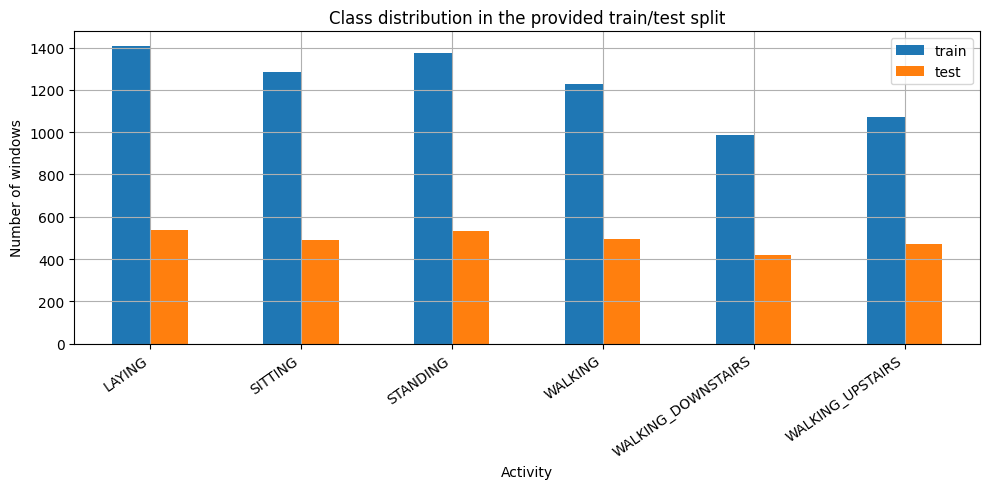

Number of train subjects: 21
Number of test subjects : 9


In [4]:
class_counts = pd.DataFrame({
    "train": y_train_names.value_counts().sort_index(),
    "test": y_test_names.value_counts().sort_index()
})
display(class_counts)

fig, ax = plt.subplots()
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Class distribution in the provided train/test split")
ax.set_xlabel("Activity")
ax.set_ylabel("Number of windows")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("Number of train subjects:", subjects_train.nunique())
print("Number of test subjects :", subjects_test.nunique())

## subject-aware validation inside the training set

The official UCI HAR split separates subjects between train and test, which is appropriate because a deployed activity-recognition model should generalize to people it did not see during training. A random row-wise validation split would be easier but less realistic, because windows from the same person can share motion style, phone placement, and walking rhythm.

The next experiment creates a validation split inside the training data using subject groups. This is not a replacement for the official test set; it is a diagnostic for model selection. If a model looks excellent on row-wise validation but weaker on subject-wise validation, it may be exploiting subject-specific patterns.


In [5]:
from sklearn.model_selection import GroupShuffleSplit

subject_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(subject_splitter.split(X_train_feat, y_train, groups=subjects_train))

X_subtrain, X_subval = X_train_feat.iloc[train_idx], X_train_feat.iloc[val_idx]
y_subtrain, y_subval = y_train.iloc[train_idx], y_train.iloc[val_idx]
subjects_subtrain = subjects_train.iloc[train_idx]
subjects_subval = subjects_train.iloc[val_idx]

print("Subject-aware validation setup")
print("Training subjects:", sorted(subjects_subtrain.unique()))
print("Validation subjects:", sorted(subjects_subval.unique()))
print("Subtrain shape:", X_subtrain.shape, "Validation shape:", X_subval.shape)

subject_val_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE))
    ])
}

subject_val_records = []
for name, model in subject_val_models.items():
    model.fit(X_subtrain, y_subtrain)
    pred = model.predict(X_subval)
    subject_val_records.append({
        "Model": name,
        "Subject-val accuracy": accuracy_score(y_subval, pred),
        "Subject-val macro F1": f1_score(y_subval, pred, average="macro"),
        "Validation subjects": subjects_subval.nunique()
    })

subject_val_df = pd.DataFrame(subject_val_records).sort_values("Subject-val macro F1", ascending=False)
display(subject_val_df.round(4))


Subject-aware validation setup
Training subjects: [5, 6, 7, 8, 11, 14, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
Validation subjects: [1, 3, 15, 25, 27]
Subtrain shape: (5551, 561) Validation shape: (1801, 561)


,Model,Subject-val accuracy,Subject-val macro F1,Validation subjects
0,Logistic Regression,0.9567,0.9527,5
2,SVM RBF,0.9500,0.9453,5
1,Random Forest,0.9311,0.9228,5


## Classical machine learning on precomputed features

Many practical sensor classification systems use handcrafted features. A raw window is converted into a fixed-length vector using statistics such as mean, standard deviation, energy, entropy, and frequency-domain summaries. This often works surprisingly well because domain-specific feature engineering encodes useful signal structure.

We first train several classical baselines on the official UCI feature matrix.

In [6]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name, labels=None):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
        "Training time (s)": train_time
    }
    return metrics, y_pred, model

def plot_confusion(y_true, y_pred, title, normalize=False):
    labels = sorted(np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true" if normalize else None)
    names = [id_to_activity[i] for i in labels]
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

classical_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

classical_results = []
classical_predictions = {}
fitted_classical_models = {}

for name, model in classical_models.items():
    metrics, pred, fitted = evaluate_classifier(model, X_train_feat, y_train, X_test_feat, y_test, name)
    classical_results.append(metrics)
    classical_predictions[name] = pred
    fitted_classical_models[name] = fitted

classical_df = pd.DataFrame(classical_results).sort_values("Macro F1", ascending=False)
display(classical_df.round(4))

,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
0,Logistic Regression,0.9549,0.9547,0.9548,40.8405
2,SVM RBF,0.9549,0.9540,0.9547,27.6927
1,Random Forest,0.9287,0.9271,0.9285,68.4314
3,KNN,0.8802,0.8766,0.8790,0.1175


Best classical model by macro F1: Logistic Regression
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.96      0.95      0.95       471
WALKING_DOWNSTAIRS       0.99      0.94      0.97       420
           SITTING       0.97      0.87      0.92       491
          STANDING       0.89      0.97      0.93       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



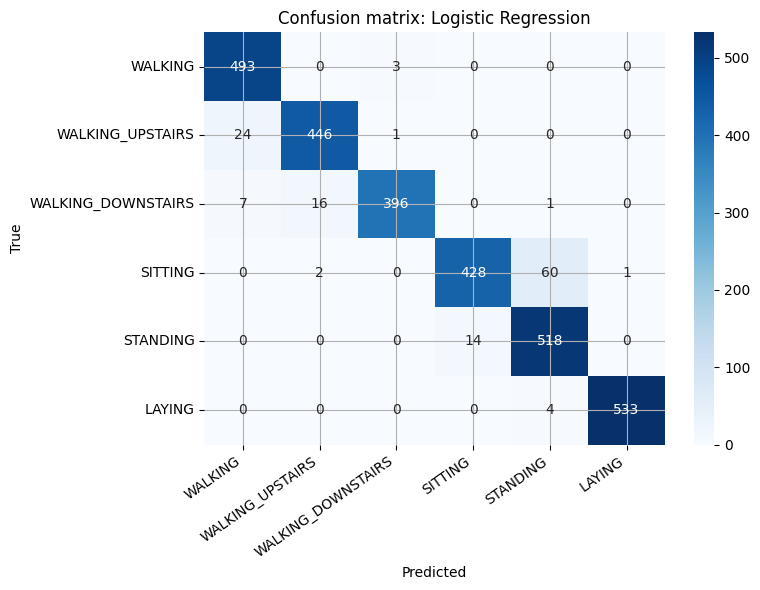

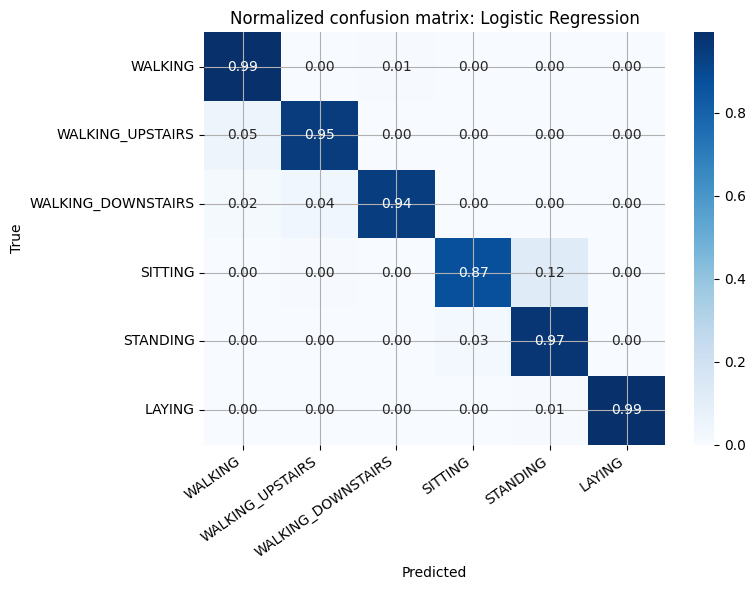

In [7]:
best_classical_name = classical_df.iloc[0]["Model"]
best_classical_pred = classical_predictions[best_classical_name]

print("Best classical model by macro F1:", best_classical_name)
print(classification_report(y_test, best_classical_pred, target_names=[id_to_activity[i] for i in sorted(id_to_activity)]))

plot_confusion(y_test, best_classical_pred, f"Confusion matrix: {best_classical_name}", normalize=False)
plot_confusion(y_test, best_classical_pred, f"Normalized confusion matrix: {best_classical_name}", normalize=True)

### why the precomputed-feature baseline is expected to be strong

The UCI feature matrix is not a weak baseline. It contains many domain-engineered time-domain and frequency-domain descriptors. Therefore, a strong SVM or Random Forest on these features may match or outperform a raw-signal neural network, especially when the deep model is intentionally lightweight and trained for only a few epochs. This is an important practical lesson: deep learning is not automatically superior when high-quality handcrafted features already summarize the signal well.


## KNN hyperparameter effect

KNN classifies a sample based on nearby examples in feature space. The choice of `k` controls locality. A very small `k` may overfit local noise. A very large `k` may smooth over meaningful class boundaries.

,k,train_accuracy,test_accuracy,test_macro_f1
0,1,1.0000,0.8534,0.8509
1,3,0.9918,0.8728,0.8699
2,5,0.9829,0.8802,0.8766
3,7,0.9782,0.8863,0.8830
4,11,0.9717,0.8843,0.8809
5,15,0.9678,0.8863,0.8827
6,21,0.9612,0.8839,0.8800


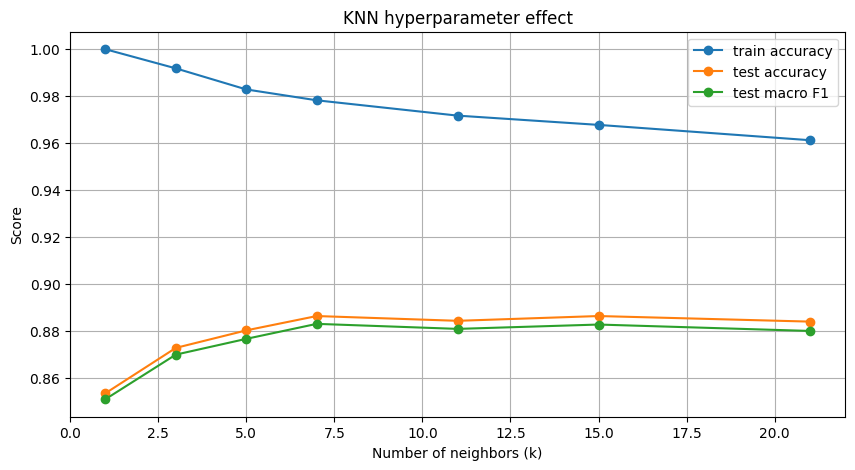

In [8]:
knn_records = []
for k in [1, 3, 5, 7, 11, 15, 21]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train_feat, y_train)
    train_pred = model.predict(X_train_feat)
    test_pred = model.predict(X_test_feat)
    knn_records.append({
        "k": k,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro")
    })

knn_df = pd.DataFrame(knn_records)
display(knn_df.round(4))

fig, ax = plt.subplots()
ax.plot(knn_df["k"], knn_df["train_accuracy"], marker="o", label="train accuracy")
ax.plot(knn_df["k"], knn_df["test_accuracy"], marker="o", label="test accuracy")
ax.plot(knn_df["k"], knn_df["test_macro_f1"], marker="o", label="test macro F1")
ax.set_title("KNN hyperparameter effect")
ax.set_xlabel("Number of neighbors (k)")
ax.set_ylabel("Score")
ax.legend()
plt.show()

## SVM hyperparameter effect

SVM tries to find a decision boundary with maximum margin. A linear SVM learns a linear boundary in feature space. An RBF SVM can learn nonlinear boundaries.

The parameter `C` controls margin softness. Larger `C` penalizes errors more strongly and may fit the training set more tightly. For RBF kernels, `gamma` controls how local the decision boundary is. Large `gamma` can create very local, potentially overfitted boundaries.

In [9]:
svm_settings = [
    {"kernel": "linear", "C": 0.1, "gamma": "scale"},
    {"kernel": "linear", "C": 1.0, "gamma": "scale"},
    {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
    {"kernel": "rbf", "C": 10.0, "gamma": "scale"},
    {"kernel": "rbf", "C": 10.0, "gamma": 0.01},
    {"kernel": "rbf", "C": 100.0, "gamma": 0.01},
]

svm_records = []
for params in svm_settings:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(**params, random_state=RANDOM_STATE))
    ])
    start = time.time()
    model.fit(X_train_feat, y_train)
    elapsed = time.time() - start
    pred = model.predict(X_test_feat)
    svm_records.append({
        **params,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "training_time_s": elapsed
    })

svm_df = pd.DataFrame(svm_records)
display(svm_df.round(4))

,kernel,C,gamma,accuracy,macro_f1,training_time_s
0,linear,0.1,scale,0.9617,0.9615,2.2025
1,linear,1.0,scale,0.9610,0.9608,2.7717
2,rbf,1.0,scale,0.9522,0.9515,5.1594
3,rbf,10.0,scale,0.9549,0.9540,5.0134
4,rbf,10.0,0.01,0.8948,0.8943,23.6996
5,rbf,100.0,0.01,0.8948,0.8943,15.9078


## Random Forest hyperparameter effect

Random Forest combines many decision trees trained on bootstrapped samples and random feature subsets. More trees generally stabilize performance but increase computation. Depth controls how complex each tree can become. Larger leaf size smooths decision rules and may reduce overfitting.

,n_estimators,max_depth,min_samples_leaf,train_accuracy,test_accuracy,test_macro_f1
0,50,10.0,1,0.9961,0.9192,0.9170
1,100,20.0,1,1.0000,0.9277,0.9262
2,200,NaN,1,1.0000,0.9287,0.9270
3,200,20.0,5,0.9981,0.9257,0.9234
4,200,10.0,10,0.9902,0.9233,0.9209


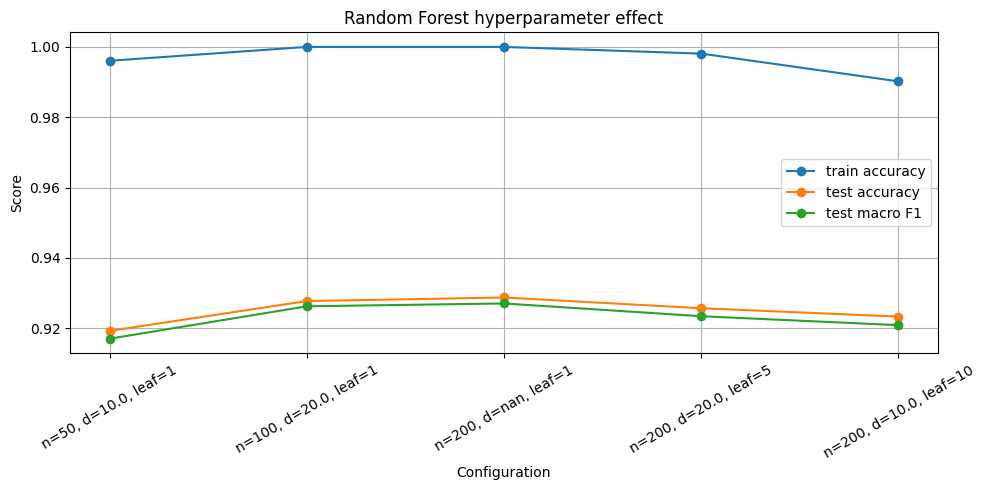

In [10]:
rf_settings = [
    {"n_estimators": 50, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 20, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 10},
]

rf_records = []
for params in rf_settings:
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train_feat, y_train)
    train_pred = model.predict(X_train_feat)
    test_pred = model.predict(X_test_feat)
    rf_records.append({
        **params,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro")
    })

rf_df = pd.DataFrame(rf_records)
display(rf_df.round(4))

fig, ax = plt.subplots()
labels = [f"n={r.n_estimators}, d={r.max_depth}, leaf={r.min_samples_leaf}" for r in rf_df.itertuples()]
ax.plot(labels, rf_df["train_accuracy"], marker="o", label="train accuracy")
ax.plot(labels, rf_df["test_accuracy"], marker="o", label="test accuracy")
ax.plot(labels, rf_df["test_macro_f1"], marker="o", label="test macro F1")
ax.set_title("Random Forest hyperparameter effect")
ax.set_xlabel("Configuration")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance from a classical model

Feature importance can reveal which engineered summaries a model relies on, but it does not prove causality. A feature may appear important because it is correlated with another signal or because of how the model partitions the feature space.

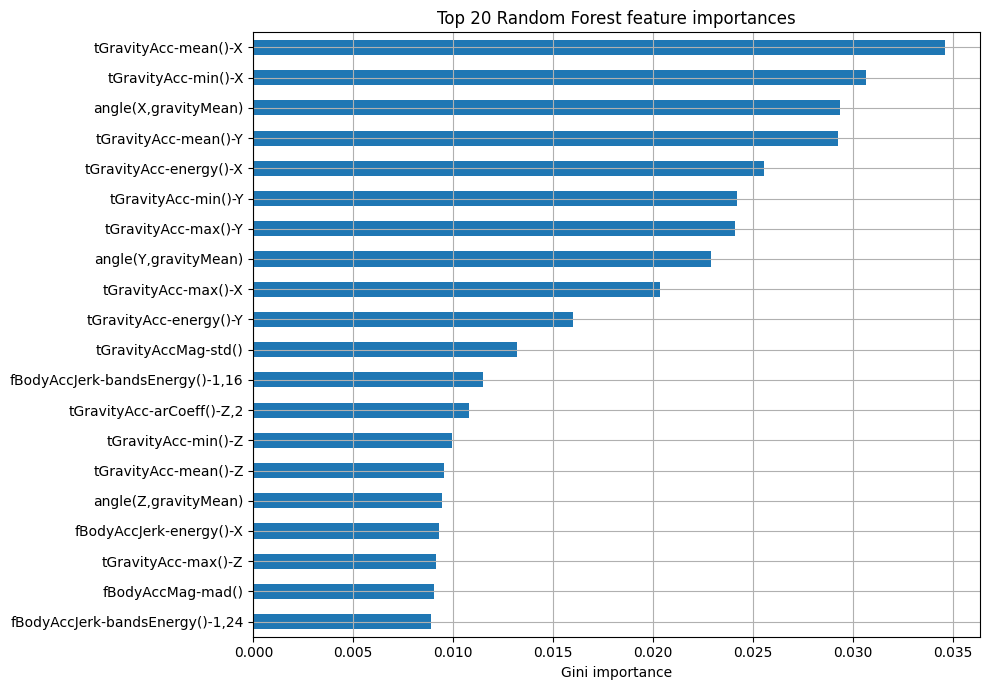

,importance
tGravityAcc-mean()-X,0.03463
tGravityAcc-min()-X,0.03068
"angle(X,gravityMean)",0.02935
tGravityAcc-mean()-Y,0.02924
tGravityAcc-energy()-X,0.02558
tGravityAcc-min()-Y,0.02423
tGravityAcc-max()-Y,0.02412
"angle(Y,gravityMean)",0.02290
tGravityAcc-max()-X,0.02036
tGravityAcc-energy()-Y,0.01602


In [11]:
rf_for_importance = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_for_importance.fit(X_train_feat, y_train)

importance = pd.Series(rf_for_importance.feature_importances_, index=X_train_feat.columns)
top_importance = importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Random Forest feature importances")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()

display(top_importance.to_frame("importance").round(5))

## time-domain versus frequency-domain feature families

The official HAR features include both time-domain features, usually starting with `t`, and frequency-domain features, usually starting with `f`. This ablation asks a practical question: how much performance comes from temporal statistics alone, and how much is added by spectral/frequency information?

After execution, compare the macro F1 values across feature families. If frequency-domain features are competitive, it suggests that periodic motion patterns are important. If time-domain features dominate, simpler amplitude and variability descriptors may already separate many activities.


,feature_family,num_features,accuracy,macro_f1,weighted_f1
0,time-domain only,265,0.9566,0.9564,0.9565
2,all official features,561,0.9549,0.9540,0.9547
1,frequency-domain only,289,0.8707,0.8721,0.8703


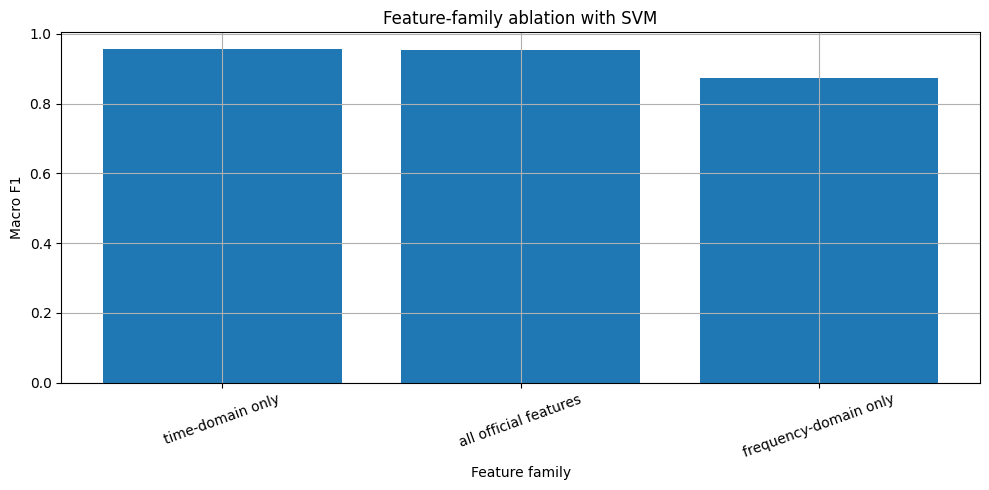

In [12]:
# UCI feature names commonly begin with t for time-domain and f for frequency-domain descriptors.
time_features = [col for col in X_train_feat.columns if col.startswith("t")]
freq_features = [col for col in X_train_feat.columns if col.startswith("f")]

feature_family_sets = {
    "time-domain only": time_features,
    "frequency-domain only": freq_features,
    "all official features": list(X_train_feat.columns)
}

family_records = []
for family_name, cols in feature_family_sets.items():
    if len(cols) == 0:
        continue
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE))
    ])
    model.fit(X_train_feat[cols], y_train)
    pred = model.predict(X_test_feat[cols])
    family_records.append({
        "feature_family": family_name,
        "num_features": len(cols),
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted")
    })

family_df = pd.DataFrame(family_records).sort_values("macro_f1", ascending=False)
display(family_df.round(4))

fig, ax = plt.subplots()
ax.bar(family_df["feature_family"], family_df["macro_f1"])
ax.set_title("Feature-family ablation with SVM")
ax.set_xlabel("Feature family")
ax.set_ylabel("Macro F1")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Raw signal loading and window representation

The raw inertial files contain fixed windows of sensor values. For UCI HAR, each window has 128 time steps. The channels include body acceleration, total acceleration, and body gyroscope signals along x, y, and z axes.

Deep models can learn directly from these sequences instead of relying only on handcrafted summaries.

In [13]:
SIGNAL_FILES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_raw_signals(split):
    signals = []
    for sig in SIGNAL_FILES:
        path = os.path.join(EXTRACTED_DIR, split, "Inertial Signals", f"{sig}_{split}.txt")
        arr = pd.read_csv(path, sep=r"\s+", header=None).values
        signals.append(arr)
    # output shape: samples x timesteps x channels
    return np.stack(signals, axis=-1)

X_train_raw = load_raw_signals("train")
X_test_raw = load_raw_signals("test")

print("Raw train shape:", X_train_raw.shape)
print("Raw test shape :", X_test_raw.shape)
print("Format: samples × timesteps × channels")

Raw train shape: (7352, 128, 9)
Raw test shape : (2947, 128, 9)
Format: samples × timesteps × channels


## Visualizing sensor signals

Dynamic activities such as walking often show larger amplitude and more periodicity. Static activities such as sitting and standing are smoother and may be harder to distinguish. These visual differences explain why both time-domain and frequency-domain information can be useful.

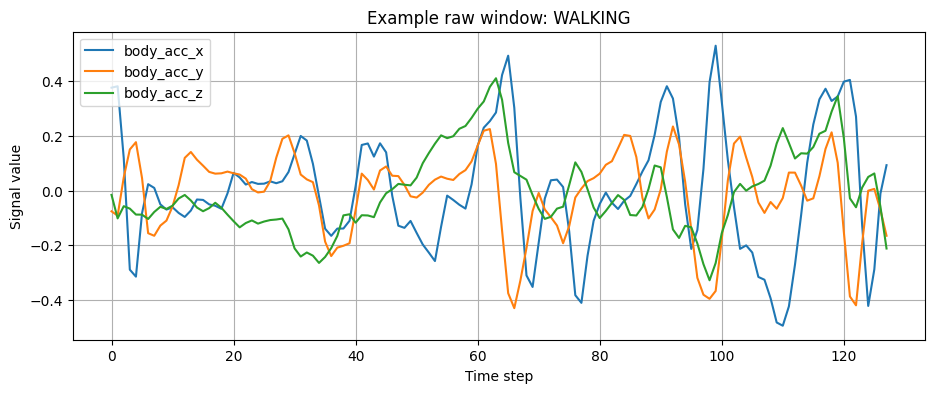

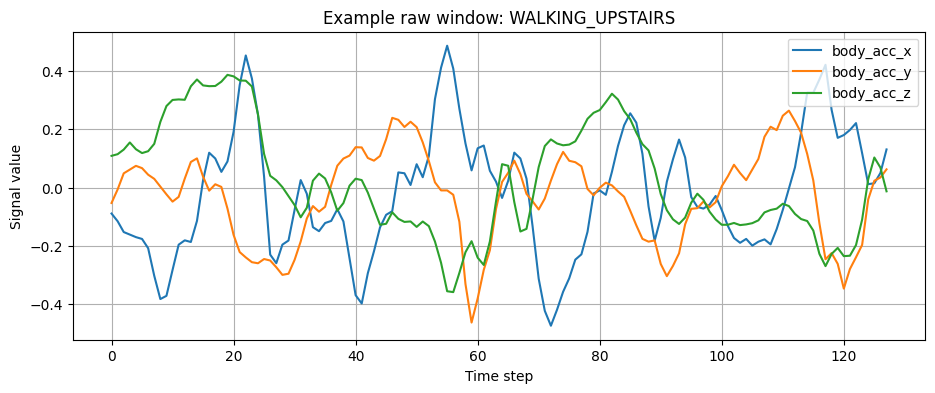

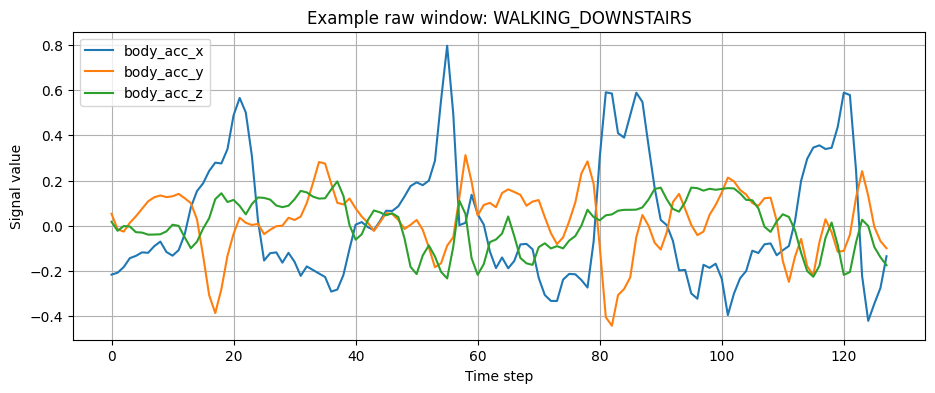

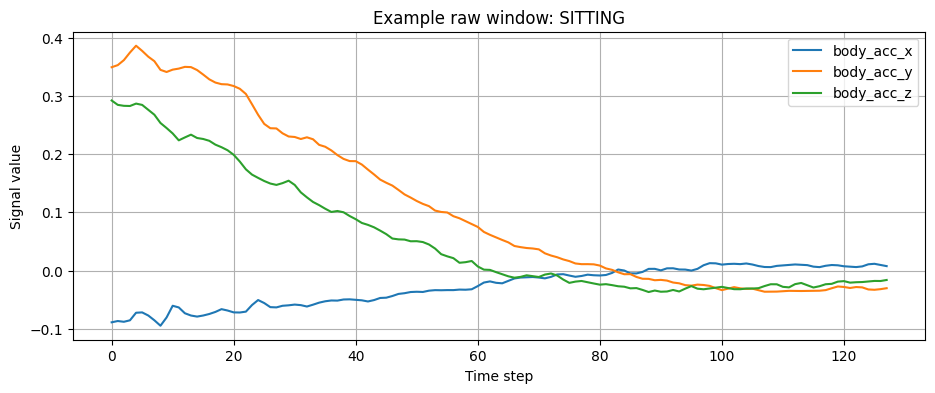

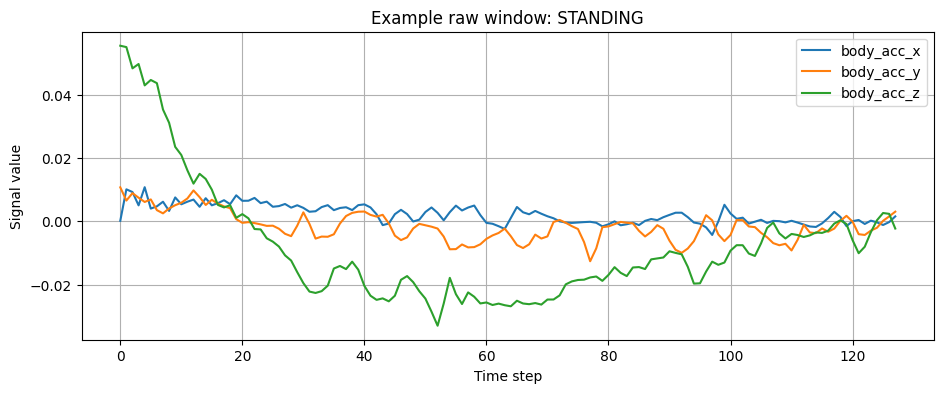

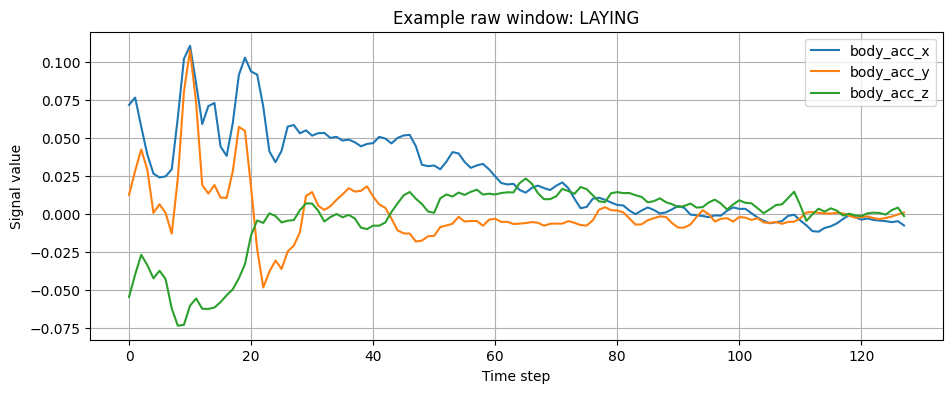

In [14]:
def plot_one_activity_window(activity_id, channel_indices=(0, 1, 2), split="train"):
    X = X_train_raw if split == "train" else X_test_raw
    y = y_train.values if split == "train" else y_test.values
    idx = np.where(y == activity_id)[0][0]
    activity_name = id_to_activity[activity_id]
    fig, ax = plt.subplots(figsize=(11, 4))
    for ch in channel_indices:
        ax.plot(X[idx, :, ch], label=SIGNAL_FILES[ch])
    ax.set_title(f"Example raw window: {activity_name}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Signal value")
    ax.legend()
    plt.show()

for activity_id in sorted(id_to_activity):
    plot_one_activity_window(activity_id, channel_indices=(0, 1, 2))

## Handcrafted statistical features from raw signals

Feature engineering for signals often combines:

- **Time-domain statistics:** mean, standard deviation, minimum, maximum, median, energy.
- **Magnitude summaries:** signal magnitude area across axes.
- **Frequency-domain statistics:** dominant frequency and spectral entropy.

These features provide a bridge between raw sequence modeling and the larger UCI precomputed feature set.

In [15]:
def zero_crossing_rate(x):
    signs = np.sign(x)
    return np.mean(signs[:, 1:] != signs[:, :-1], axis=1)

def spectral_entropy_1d(x):
    # x: samples x timesteps
    fft_power = np.abs(rfft(x, axis=1)) ** 2
    probs = fft_power / (fft_power.sum(axis=1, keepdims=True) + 1e-12)
    return entropy(probs, axis=1)

def dominant_frequency(x, sampling_rate=50.0):
    # UCI HAR used 50 Hz sampling.
    power = np.abs(rfft(x, axis=1)) ** 2
    freqs = rfftfreq(x.shape[1], d=1.0 / sampling_rate)
    # ignore the zero-frequency component
    idx = np.argmax(power[:, 1:], axis=1) + 1
    return freqs[idx]

def extract_raw_features(X):
    features = {}
    for ch, name in enumerate(SIGNAL_FILES):
        x = X[:, :, ch]
        features[f"{name}_mean"] = x.mean(axis=1)
        features[f"{name}_std"] = x.std(axis=1)
        features[f"{name}_min"] = x.min(axis=1)
        features[f"{name}_max"] = x.max(axis=1)
        features[f"{name}_median"] = np.median(x, axis=1)
        features[f"{name}_energy"] = np.mean(x ** 2, axis=1)
        features[f"{name}_zcr"] = zero_crossing_rate(x)
        features[f"{name}_dominant_freq"] = dominant_frequency(x)
        features[f"{name}_spectral_entropy"] = spectral_entropy_1d(x)

    # Signal magnitude area for accelerometer-like and gyro-like channel groups.
    body_acc_mag = np.abs(X[:, :, 0]) + np.abs(X[:, :, 1]) + np.abs(X[:, :, 2])
    body_gyro_mag = np.abs(X[:, :, 3]) + np.abs(X[:, :, 4]) + np.abs(X[:, :, 5])
    features["body_acc_signal_magnitude_area"] = body_acc_mag.mean(axis=1)
    features["body_gyro_signal_magnitude_area"] = body_gyro_mag.mean(axis=1)

    return pd.DataFrame(features)

X_train_custom = extract_raw_features(X_train_raw)
X_test_custom = extract_raw_features(X_test_raw)

print("Custom raw-feature shape:", X_train_custom.shape)
display(X_train_custom.head())

Custom raw-feature shape: (7352, 83)


,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_energy,body_acc_x_zcr,body_acc_x_dominant_freq,body_acc_x_spectral_entropy,body_acc_y_mean,...,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_energy,total_acc_z_zcr,total_acc_z_dominant_freq,total_acc_z_spectral_entropy,body_acc_signal_magnitude_area,body_gyro_signal_magnitude_area
0,0.002269,0.002941,-0.004294,0.010810,0.002025,0.000014,0.204724,0.390625,1.809541,-0.001655,...,0.003970,0.088742,0.109485,0.099841,0.009962,0.0,0.390625,0.008945,0.023390,0.052769
1,0.000174,0.001981,-0.006706,0.005251,0.000110,0.000004,0.307087,7.031250,3.300623,0.000382,...,0.004918,0.081100,0.105788,0.097748,0.009421,0.0,0.390625,0.013755,0.015118,0.033714
2,0.000428,0.002908,-0.010483,0.008167,0.000627,0.000009,0.283465,0.781250,3.312783,-0.001222,...,0.006145,0.081100,0.105788,0.093636,0.008668,0.0,0.390625,0.021291,0.014338,0.039862
3,0.000329,0.002678,-0.010483,0.008167,0.000269,0.000007,0.236220,0.390625,3.067049,-0.004753,...,0.004945,0.076888,0.098737,0.087501,0.007708,0.0,0.390625,0.016307,0.013019,0.031327
4,-0.000195,0.002015,-0.006847,0.005650,-0.000144,0.000004,0.244094,7.031250,3.285921,0.000298,...,0.003637,0.074595,0.093388,0.084765,0.007238,0.0,4.296875,0.010247,0.009712,0.027118


In [16]:
custom_models = {
    "Custom raw features + Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Custom raw features + SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE))
    ])
}

custom_results = []
custom_predictions = {}

for name, model in custom_models.items():
    metrics, pred, fitted = evaluate_classifier(model, X_train_custom, y_train, X_test_custom, y_test, name)
    custom_results.append(metrics)
    custom_predictions[name] = pred

custom_df = pd.DataFrame(custom_results).sort_values("Macro F1", ascending=False)
display(custom_df.round(4))

,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
1,Custom raw features + SVM RBF,0.9084,0.9075,0.9082,1.0007
0,Custom raw features + Random Forest,0.8989,0.8965,0.8984,16.4200


## which raw sensor channel group is more informative?

Raw HAR windows contain accelerometer and gyroscope channels. Accelerometer channels describe linear motion and gravity-related components, while gyroscope channels describe angular velocity. This small ablation builds custom statistical features from selected channel groups and trains the same Random Forest. It helps readers connect model performance to physical sensor meaning rather than treating all channels as anonymous numbers.


,channel_group,num_channels,num_features,accuracy,macro_f1
3,all channels,9,82,0.9019,0.8996
1,body gyroscope only,3,28,0.8164,0.8187
0,body acceleration only,3,28,0.7808,0.7787
2,total acceleration only,3,28,0.7764,0.7733


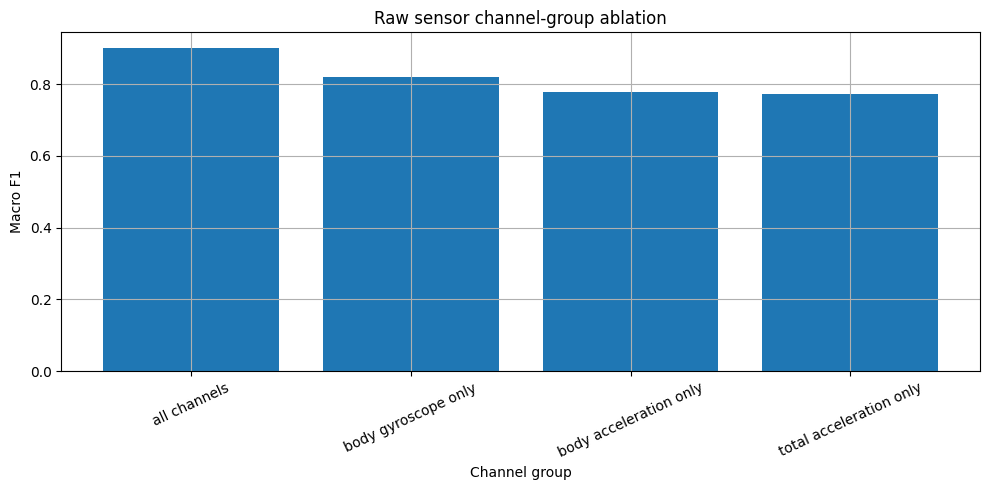

In [18]:
def extract_statistical_features(X, channel_names):
    features = {}
    for ch, name in enumerate(channel_names):
        x = X[:, :, ch]
        features[f"{name}_mean"] = x.mean(axis=1)
        features[f"{name}_std"] = x.std(axis=1)
        features[f"{name}_min"] = x.min(axis=1)
        features[f"{name}_max"] = x.max(axis=1)
        features[f"{name}_median"] = np.median(x, axis=1)
        features[f"{name}_energy"] = np.mean(x ** 2, axis=1)
        features[f"{name}_zcr"] = zero_crossing_rate(x)
        features[f"{name}_dominant_freq"] = dominant_frequency(x)
        features[f"{name}_spectral_entropy"] = spectral_entropy_1d(x)

    if X.shape[2] >= 3:
        magnitude_area = np.sum(np.abs(X[:, :, :3]), axis=2).mean(axis=1)
        features["selected_xyz_signal_magnitude_area"] = magnitude_area

    return pd.DataFrame(features)

channel_groups = {
    "body acceleration only": [0, 1, 2],
    "body gyroscope only": [3, 4, 5],
    "total acceleration only": [6, 7, 8],
    "all channels": list(range(len(SIGNAL_FILES)))
}

channel_records = []
for group_name, ch_idx in channel_groups.items():
    Xtr_group = extract_statistical_features(X_train_raw[:, :, ch_idx], [SIGNAL_FILES[i] for i in ch_idx])
    Xte_group = extract_statistical_features(X_test_raw[:, :, ch_idx], [SIGNAL_FILES[i] for i in ch_idx])
    model = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr_group, y_train)
    pred = model.predict(Xte_group)
    channel_records.append({
        "channel_group": group_name,
        "num_channels": len(ch_idx),
        "num_features": Xtr_group.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro")
    })

channel_ablation_df = pd.DataFrame(channel_records).sort_values("macro_f1", ascending=False)
display(channel_ablation_df.round(4))

fig, ax = plt.subplots()
ax.bar(channel_ablation_df["channel_group"], channel_ablation_df["macro_f1"])
ax.set_title("Raw sensor channel-group ablation")
ax.set_xlabel("Channel group")
ax.set_ylabel("Macro F1")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## Window-size experiment using cropped fixed windows

Real window-size studies require reconstructing continuous sensor streams and re-windowing them. Here, we use a controlled approximation: crop each fixed 128-step window to shorter prefixes of 32, 64, and 96 steps, then compare with the full 128-step window.

Short windows may miss complete motion cycles. Long windows capture more context but increase computation and may include mixed activities in real deployments.

In [19]:
def standardize_raw_by_train(X_train, X_test):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
    return (X_train - mean) / std, (X_test - mean) / std

X_train_raw_scaled, X_test_raw_scaled = standardize_raw_by_train(X_train_raw, X_test_raw)

if HAS_TF:
    y_train_keras = y_train.values - 1
    y_test_keras = y_test.values - 1
    num_classes = len(id_to_activity)
    print("Prepared Keras labels from 0 to", num_classes - 1)
else:
    print("TensorFlow not available: window-size and deep-learning training cells will be skipped.")

Prepared Keras labels from 0 to 5


## 1D CNN model

A 1D CNN applies convolution along the time axis. It detects local temporal patterns such as peaks, repeated fragments, and short-term transitions. Kernel size controls the temporal span of each local pattern. More filters increase capacity. Dropout reduces overfitting.

In [20]:
def build_cnn(input_shape, num_classes, filters=64, kernel_size=5, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters, kernel_size, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters * 2, kernel_size, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(dropout),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_keras_model(model, X_test, y_test_zero, model_name):
    probs = model.predict(X_test, verbose=0)
    pred_zero = probs.argmax(axis=1)
    pred_labels = pred_zero + 1
    true_labels = y_test_zero + 1
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(true_labels, pred_labels),
        "Macro F1": f1_score(true_labels, pred_labels, average="macro"),
        "Weighted F1": f1_score(true_labels, pred_labels, average="weighted")
    }, pred_labels, probs

deep_results = []
deep_predictions = {}
histories = {}

In [21]:
if HAS_TF:
    cnn_model = build_cnn(
        input_shape=X_train_raw_scaled.shape[1:],
        num_classes=num_classes,
        filters=64,
        kernel_size=5,
        dropout=0.3
    )
    start = time.time()
    history = cnn_model.fit(
        X_train_raw_scaled, y_train_keras,
        validation_split=0.15,
        epochs=10,
        batch_size=128,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy")
        ]
    )
    train_time = time.time() - start
    metrics, pred, probs = evaluate_keras_model(cnn_model, X_test_raw_scaled, y_test_keras, "Raw signals + 1D CNN")
    metrics["Training time (s)"] = train_time
    deep_results.append(metrics)
    deep_predictions["Raw signals + 1D CNN"] = pred
    histories["Raw signals + 1D CNN"] = history

    display(pd.DataFrame(deep_results).round(4))
else:
    print("Skipped because TensorFlow is not available.")

Epoch 1/10
49/49 [==============================] - 25s 108ms/step - loss: 0.4172 - accuracy: 0.8579 - val_loss: 0.8666 - val_accuracy: 0.8595
Epoch 2/10
49/49 [==============================] - 1s 16ms/step - loss: 0.1365 - accuracy: 0.9525 - val_loss: 0.4940 - val_accuracy: 0.8849
Epoch 3/10
49/49 [==============================] - 1s 16ms/step - loss: 0.1107 - accuracy: 0.9563 - val_loss: 0.3082 - val_accuracy: 0.9084
Epoch 4/10
49/49 [==============================] - 1s 17ms/step - loss: 0.0942 - accuracy: 0.9590 - val_loss: 0.2657 - val_accuracy: 0.9166
Epoch 5/10
49/49 [==============================] - 1s 17ms/step - loss: 0.0895 - accuracy: 0.9622 - val_loss: 0.2836 - val_accuracy: 0.9102
Epoch 6/10
49/49 [==============================] - 1s 21ms/step - loss: 0.0893 - accuracy: 0.9611 - val_loss: 0.3190 - val_accuracy: 0.8994
Epoch 7/10
49/49 [==============================] - 1s 17ms/step - loss: 0.0798 - accuracy: 0.9645 - val_loss: 0.4036 - val_accuracy: 0.8985


,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
0,Raw signals + 1D CNN,0.9121,0.9117,0.9116,29.995


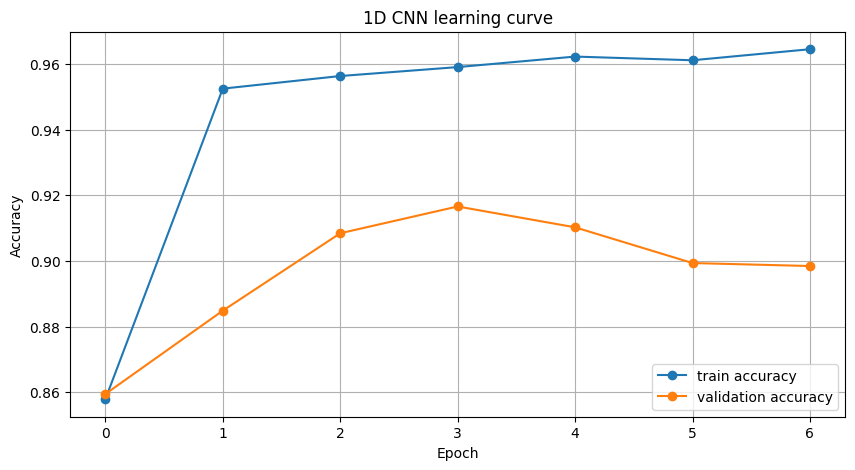

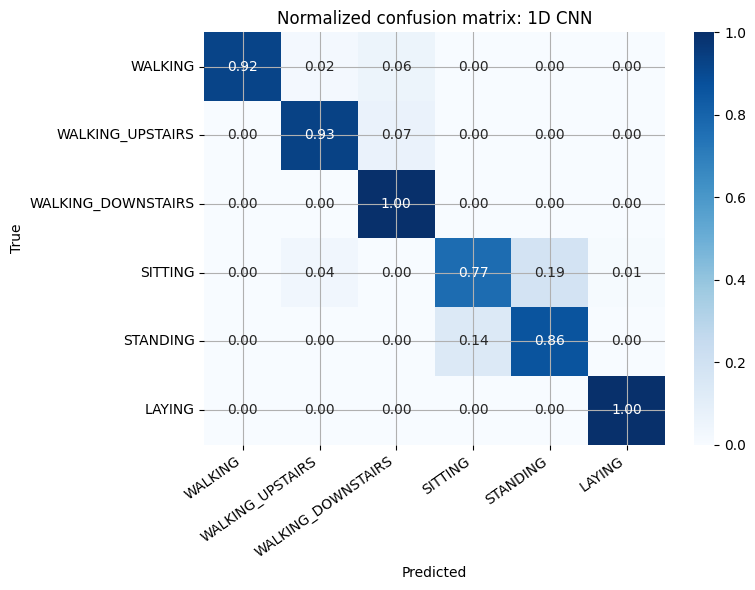

In [22]:
if HAS_TF and "Raw signals + 1D CNN" in histories:
    hist = histories["Raw signals + 1D CNN"].history
    fig, ax = plt.subplots()
    ax.plot(hist["accuracy"], marker="o", label="train accuracy")
    ax.plot(hist["val_accuracy"], marker="o", label="validation accuracy")
    ax.set_title("1D CNN learning curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.show()

    plot_confusion(y_test, deep_predictions["Raw signals + 1D CNN"], "Normalized confusion matrix: 1D CNN", normalize=True)

### CNN hyperparameter effect

The comparisons below are deliberately small. The goal is to understand how kernel size and number of filters affect behavior, not to perform an expensive brute-force search.

,filters,kernel_size,dropout,Model,Accuracy,Macro F1,Weighted F1
0,32,3,0.3,"CNN {'filters': 32, 'kernel_size': 3, 'dropout...",0.9006,0.9016,0.9008
1,64,5,0.3,"CNN {'filters': 64, 'kernel_size': 5, 'dropout...",0.9063,0.9075,0.9063
2,64,7,0.3,"CNN {'filters': 64, 'kernel_size': 7, 'dropout...",0.9220,0.9232,0.9217
3,64,5,0.5,"CNN {'filters': 64, 'kernel_size': 5, 'dropout...",0.9182,0.9184,0.9179


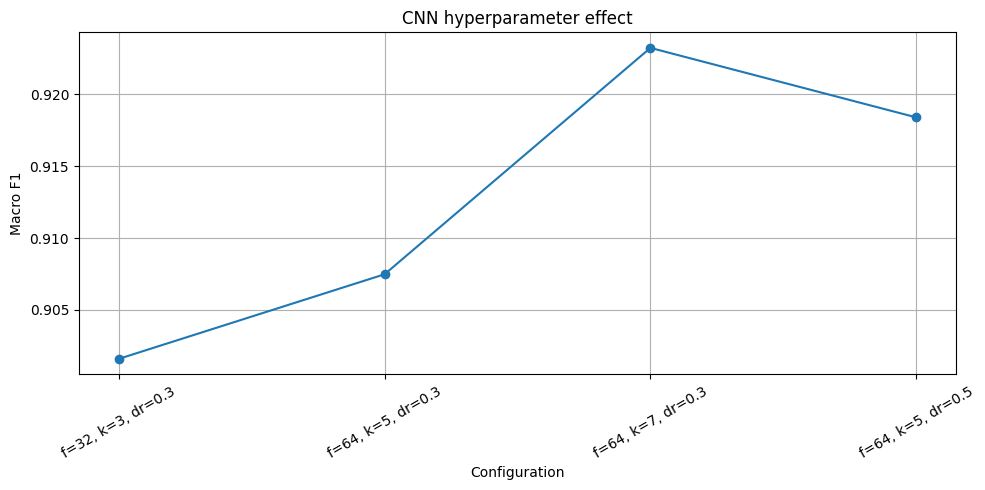

In [23]:
if HAS_TF:
    cnn_hp_records = []
    hp_settings = [
        {"filters": 32, "kernel_size": 3, "dropout": 0.3},
        {"filters": 64, "kernel_size": 5, "dropout": 0.3},
        {"filters": 64, "kernel_size": 7, "dropout": 0.3},
        {"filters": 64, "kernel_size": 5, "dropout": 0.5},
    ]

    # Use fewer epochs for the hyperparameter effect section.
    for params in hp_settings:
        model = build_cnn(X_train_raw_scaled.shape[1:], num_classes, **params)
        model.fit(
            X_train_raw_scaled, y_train_keras,
            validation_split=0.15,
            epochs=5,
            batch_size=128,
            verbose=0
        )
        eval_metrics, _, _ = evaluate_keras_model(
            model, X_test_raw_scaled, y_test_keras,
            f"CNN {params}"
        )
        cnn_hp_records.append({**params, **eval_metrics})

    cnn_hp_df = pd.DataFrame(cnn_hp_records)
    display(cnn_hp_df.round(4))

    fig, ax = plt.subplots()
    labels = [f"f={r.filters}, k={r.kernel_size}, dr={r.dropout}" for r in cnn_hp_df.itertuples()]
    ax.plot(labels, cnn_hp_df["Macro F1"], marker="o")
    ax.set_title("CNN hyperparameter effect")
    ax.set_xlabel("Configuration")
    ax.set_ylabel("Macro F1")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped because TensorFlow is not available.")

## LSTM/GRU model

LSTM and GRU networks process sequences step by step while maintaining a hidden state. This can capture dependencies across the window. However, recurrent models may train slower than CNNs. For short fixed windows, CNNs often perform competitively because local motion patterns are highly informative.

In [24]:
def build_gru(input_shape, num_classes, units=64, dropout=0.3):
    inputs = keras.Input(shape=input_shape)
    x = layers.GRU(units, dropout=dropout, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

if HAS_TF:
    gru_model = build_gru(X_train_raw_scaled.shape[1:], num_classes, units=64, dropout=0.3)
    start = time.time()
    history = gru_model.fit(
        X_train_raw_scaled, y_train_keras,
        validation_split=0.15,
        epochs=10,
        batch_size=128,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy")
        ]
    )
    train_time = time.time() - start
    metrics, pred, probs = evaluate_keras_model(gru_model, X_test_raw_scaled, y_test_keras, "Raw signals + GRU")
    metrics["Training time (s)"] = train_time
    deep_results.append(metrics)
    deep_predictions["Raw signals + GRU"] = pred
    histories["Raw signals + GRU"] = history

    display(pd.DataFrame(deep_results).round(4))
else:
    print("Skipped because TensorFlow is not available.")

Epoch 1/10
49/49 [==============================] - 6s 56ms/step - loss: 1.3655 - accuracy: 0.4974 - val_loss: 1.1693 - val_accuracy: 0.5920
Epoch 2/10
49/49 [==============================] - 2s 40ms/step - loss: 0.8528 - accuracy: 0.6739 - val_loss: 0.7703 - val_accuracy: 0.7398
Epoch 3/10
49/49 [==============================] - 2s 34ms/step - loss: 0.5265 - accuracy: 0.7763 - val_loss: 0.5511 - val_accuracy: 0.8087
Epoch 4/10
49/49 [==============================] - 1s 28ms/step - loss: 0.3782 - accuracy: 0.8225 - val_loss: 0.5273 - val_accuracy: 0.8141
Epoch 5/10
49/49 [==============================] - 1s 29ms/step - loss: 0.3173 - accuracy: 0.8598 - val_loss: 0.4539 - val_accuracy: 0.8477
Epoch 6/10
49/49 [==============================] - 2s 31ms/step - loss: 0.2482 - accuracy: 0.9088 - val_loss: 0.4474 - val_accuracy: 0.8450
Epoch 7/10
49/49 [==============================] - 1s 29ms/step - loss: 0.1525 - accuracy: 0.9490 - val_loss: 0.3885 - val_accuracy: 0.8586
Epoch 8/10
49

,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
0,Raw signals + 1D CNN,0.9121,0.9117,0.9116,29.9950
1,Raw signals + GRU,0.8911,0.8926,0.8914,19.8257


## Transformer encoder basics

A Transformer encoder uses self-attention to compare time steps with each other. Instead of processing a sequence strictly step by step, it learns which time positions should attend to other positions. This is powerful but may require more data and regularization than simpler CNNs.

In [25]:
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout=0.2):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ff_output = layers.Dense(ff_dim, activation="relu")(x)
    ff_output = layers.Dense(embed_dim)(ff_output)
    ff_output = layers.Dropout(dropout)(ff_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff_output)
    return x

def build_transformer(input_shape, num_classes, embed_dim=64, num_heads=4, ff_dim=128, dropout=0.3):
    inputs = keras.Input(shape=input_shape)
    x = layers.Dense(embed_dim)(inputs)
    x = transformer_encoder_block(x, embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

if HAS_TF:
    transformer_model = build_transformer(
        X_train_raw_scaled.shape[1:], num_classes,
        embed_dim=64, num_heads=4, ff_dim=128, dropout=0.3
    )
    start = time.time()
    history = transformer_model.fit(
        X_train_raw_scaled, y_train_keras,
        validation_split=0.15,
        epochs=10,
        batch_size=128,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy")
        ]
    )
    train_time = time.time() - start
    metrics, pred, probs = evaluate_keras_model(transformer_model, X_test_raw_scaled, y_test_keras, "Raw signals + Transformer")
    metrics["Training time (s)"] = train_time
    deep_results.append(metrics)
    deep_predictions["Raw signals + Transformer"] = pred
    histories["Raw signals + Transformer"] = history

    display(pd.DataFrame(deep_results).round(4))
else:
    print("Skipped because TensorFlow is not available.")

Epoch 1/10
49/49 [==============================] - 5s 50ms/step - loss: 0.7197 - accuracy: 0.7310 - val_loss: 0.4724 - val_accuracy: 0.8468
Epoch 2/10
49/49 [==============================] - 2s 39ms/step - loss: 0.2390 - accuracy: 0.9224 - val_loss: 0.3903 - val_accuracy: 0.8821
Epoch 3/10
49/49 [==============================] - 2s 39ms/step - loss: 0.1451 - accuracy: 0.9454 - val_loss: 0.3218 - val_accuracy: 0.8912
Epoch 4/10
49/49 [==============================] - 2s 39ms/step - loss: 0.1272 - accuracy: 0.9515 - val_loss: 0.3196 - val_accuracy: 0.9021
Epoch 5/10
49/49 [==============================] - 2s 38ms/step - loss: 0.1098 - accuracy: 0.9555 - val_loss: 0.3481 - val_accuracy: 0.9012
Epoch 6/10
49/49 [==============================] - 2s 38ms/step - loss: 0.1009 - accuracy: 0.9578 - val_loss: 0.3863 - val_accuracy: 0.9075
Epoch 7/10
49/49 [==============================] - 2s 38ms/step - loss: 0.0962 - accuracy: 0.9584 - val_loss: 0.4154 - val_accuracy: 0.9121
Epoch 8/10
49

,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
0,Raw signals + 1D CNN,0.9121,0.9117,0.9116,29.9950
1,Raw signals + GRU,0.8911,0.8926,0.8914,19.8257
2,Raw signals + Transformer,0.8785,0.8753,0.8780,21.9641


## Window-length effect with a simple CNN

The fixed 128-step UCI windows can be cropped to simulate shorter windows. This does not perfectly reproduce real streaming segmentation, but it helps illustrate why temporal context matters.

,window_length,Model,Accuracy,Macro F1,Weighted F1
0,32,CNN window=32,0.8955,0.8961,0.8955
1,64,CNN window=64,0.9084,0.9089,0.9086
2,96,CNN window=96,0.9247,0.9258,0.9248
3,128,CNN window=128,0.9087,0.9094,0.9087


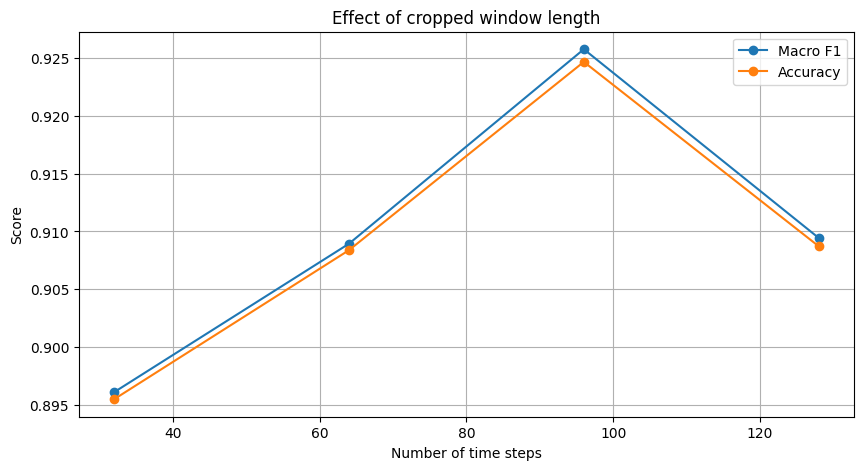

In [26]:
if HAS_TF:
    window_records = []
    for window_len in [32, 64, 96, 128]:
        Xtr = X_train_raw_scaled[:, :window_len, :]
        Xte = X_test_raw_scaled[:, :window_len, :]
        model = build_cnn(Xtr.shape[1:], num_classes, filters=32, kernel_size=5, dropout=0.3)
        model.fit(
            Xtr, y_train_keras,
            validation_split=0.15,
            epochs=5,
            batch_size=128,
            verbose=0
        )
        metrics, _, _ = evaluate_keras_model(model, Xte, y_test_keras, f"CNN window={window_len}")
        window_records.append({"window_length": window_len, **metrics})

    window_df = pd.DataFrame(window_records)
    display(window_df.round(4))

    fig, ax = plt.subplots()
    ax.plot(window_df["window_length"], window_df["Macro F1"], marker="o", label="Macro F1")
    ax.plot(window_df["window_length"], window_df["Accuracy"], marker="o", label="Accuracy")
    ax.set_title("Effect of cropped window length")
    ax.set_xlabel("Number of time steps")
    ax.set_ylabel("Score")
    ax.legend()
    plt.show()
else:
    print("Skipped because TensorFlow is not available.")

## Deep learning model comparison

After execution, compare whether raw deep models provide a meaningful gain over the handcrafted-feature baselines. If the improvement is small, the simpler feature-based model may be preferable because it is faster, easier to interpret, and easier to deploy.

In [27]:
comparison_parts = [classical_df, custom_df]
if deep_results:
    comparison_parts.append(pd.DataFrame(deep_results))

model_comparison = pd.concat(comparison_parts, ignore_index=True, sort=False)
model_comparison = model_comparison.sort_values("Macro F1", ascending=False).reset_index(drop=True)
display(model_comparison.round(4))

,Model,Accuracy,Macro F1,Weighted F1,Training time (s)
0,Logistic Regression,0.9549,0.9547,0.9548,40.8405
1,SVM RBF,0.9549,0.9540,0.9547,27.6927
2,Random Forest,0.9287,0.9271,0.9285,68.4314
3,Raw signals + 1D CNN,0.9121,0.9117,0.9116,29.9950
4,Custom raw features + SVM RBF,0.9084,0.9075,0.9082,1.0007
5,Custom raw features + Random Forest,0.8989,0.8965,0.8984,16.4200
6,Raw signals + GRU,0.8911,0.8926,0.8914,19.8257
7,KNN,0.8802,0.8766,0.8790,0.1175
8,Raw signals + Transformer,0.8785,0.8753,0.8780,21.9641


## Class-wise performance

Overall accuracy is useful, but it can hide systematic errors. In human activity recognition, common confusions include:

- Sitting vs standing
- Walking upstairs vs walking downstairs
- Walking activities vs transition-like windows

The normalized confusion matrix helps reveal whether a model fails consistently for specific activity pairs.

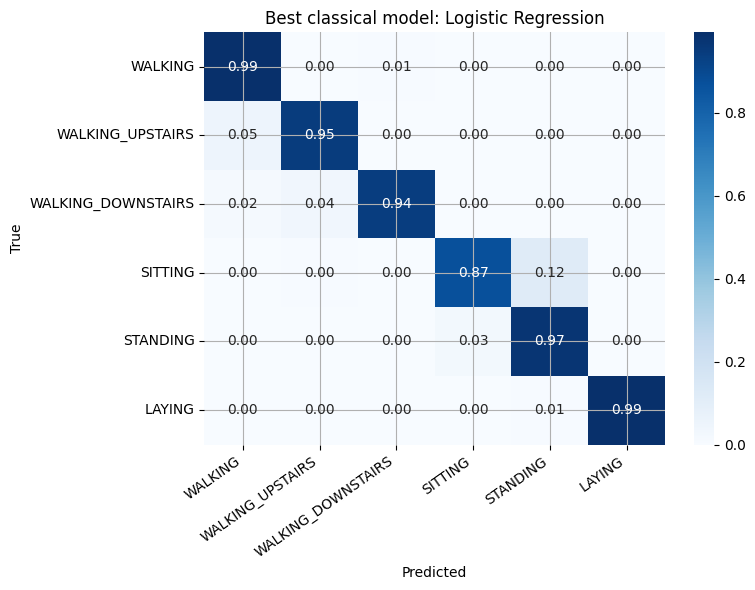

Best deep model by macro F1: Raw signals + 1D CNN
                    precision    recall  f1-score   support

           WALKING       1.00      0.92      0.96       496
  WALKING_UPSTAIRS       0.94      0.93      0.93       471
WALKING_DOWNSTAIRS       0.87      1.00      0.93       420
           SITTING       0.84      0.77      0.80       491
          STANDING       0.83      0.86      0.85       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



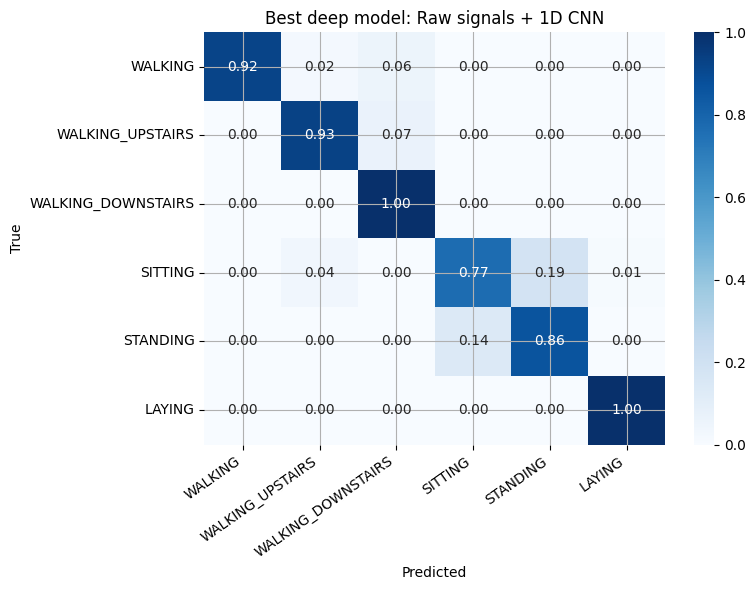

In [28]:
# Compare the strongest available models from classical and deep families.
plot_confusion(y_test, best_classical_pred, f"Best classical model: {best_classical_name}", normalize=True)

if deep_predictions:
    best_deep_name = pd.DataFrame(deep_results).sort_values("Macro F1", ascending=False).iloc[0]["Model"]
    best_deep_pred = deep_predictions[best_deep_name]
    print("Best deep model by macro F1:", best_deep_name)
    print(classification_report(y_test, best_deep_pred, target_names=[id_to_activity[i] for i in sorted(id_to_activity)]))
    plot_confusion(y_test, best_deep_pred, f"Best deep model: {best_deep_name}", normalize=True)
else:
    print("No deep model predictions available. Install TensorFlow and rerun the deep-learning sections.")

### class-wise error table: most common confusion pairs

A confusion matrix is visually useful, but a ranked table of confusion pairs makes the most systematic mistakes easier to discuss. This is especially helpful for reports or GitHub readers who want to know whether the model confuses physically similar activities.


In [29]:
def confusion_pair_table(y_true, y_pred, top_n=10):
    rows = []
    for true_label, pred_label in zip(np.asarray(y_true), np.asarray(y_pred)):
        if true_label != pred_label:
            rows.append({
                "true_activity": id_to_activity[int(true_label)],
                "predicted_activity": id_to_activity[int(pred_label)]
            })
    if not rows:
        return pd.DataFrame(columns=["true_activity", "predicted_activity", "count"])
    return (pd.DataFrame(rows)
            .value_counts(["true_activity", "predicted_activity"])
            .reset_index(name="count")
            .head(top_n))

print("Most common confusion pairs for the best classical model")
display(confusion_pair_table(y_test, best_classical_pred, top_n=10))

if deep_predictions:
    print("Most common confusion pairs for the best deep model")
    display(confusion_pair_table(y_test, best_deep_pred, top_n=10))


Most common confusion pairs for the best classical model


,true_activity,predicted_activity,count
0,SITTING,STANDING,60
1,WALKING_UPSTAIRS,WALKING,24
2,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,16
3,STANDING,SITTING,14
4,WALKING_DOWNSTAIRS,WALKING,7
5,LAYING,STANDING,4
6,WALKING,WALKING_DOWNSTAIRS,3
7,SITTING,WALKING_UPSTAIRS,2
8,SITTING,LAYING,1
9,WALKING_DOWNSTAIRS,STANDING,1


Most common confusion pairs for the best deep model


,true_activity,predicted_activity,count
0,SITTING,STANDING,91
1,STANDING,SITTING,73
2,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,33
3,WALKING,WALKING_DOWNSTAIRS,28
4,SITTING,WALKING_UPSTAIRS,19
5,WALKING,WALKING_UPSTAIRS,10
6,SITTING,LAYING,5


## Error analysis

Error analysis matters because high accuracy can still hide meaningful failure modes. A useful next step is to inspect examples where the model confuses physically similar activities.

Number of misclassified test samples: 259


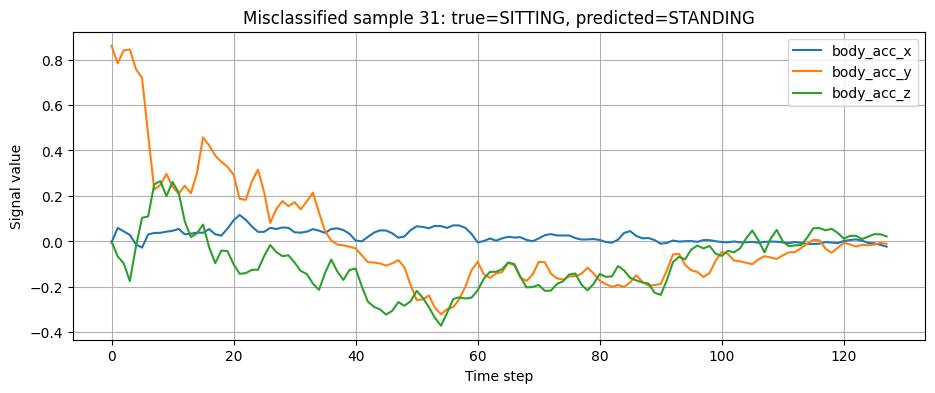

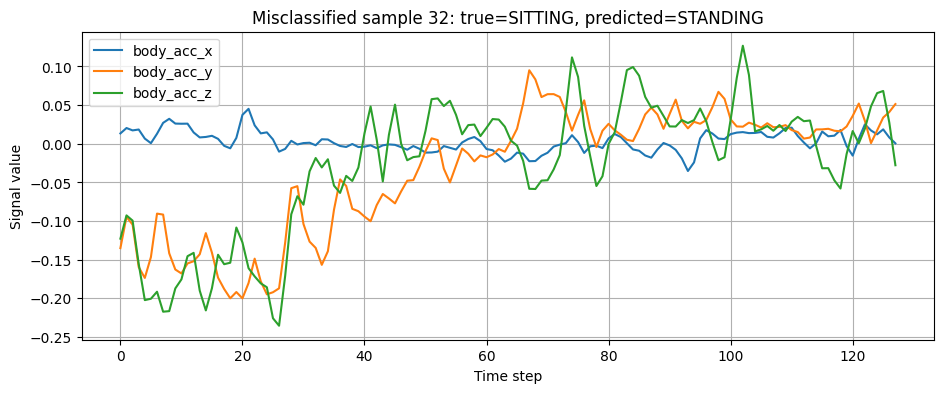

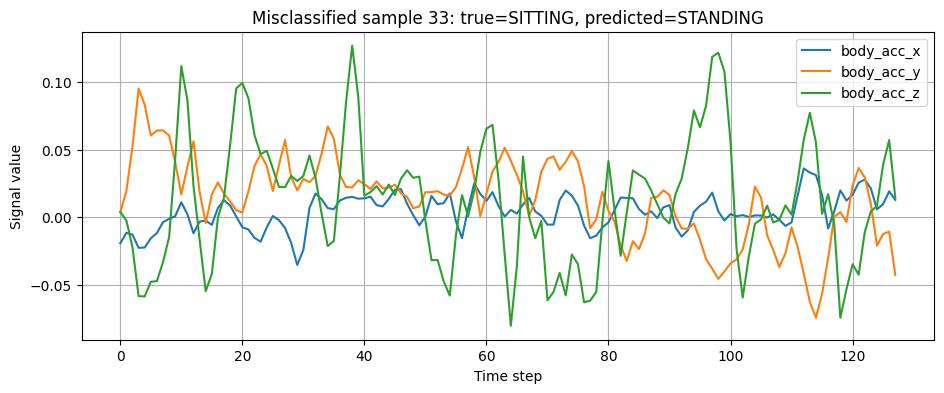

In [30]:
def inspect_misclassified_samples(y_true, y_pred, X_raw, max_examples=3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    wrong = np.where(y_true != y_pred)[0]
    print("Number of misclassified test samples:", len(wrong))

    for idx in wrong[:max_examples]:
        true_name = id_to_activity[int(y_true[idx])]
        pred_name = id_to_activity[int(y_pred[idx])]
        fig, ax = plt.subplots(figsize=(11, 4))
        for ch in [0, 1, 2]:
            ax.plot(X_raw[idx, :, ch], label=SIGNAL_FILES[ch])
        ax.set_title(f"Misclassified sample {idx}: true={true_name}, predicted={pred_name}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Signal value")
        ax.legend()
        plt.show()

if deep_predictions:
    inspect_misclassified_samples(y_test.values, best_deep_pred, X_test_raw_scaled, max_examples=3)
else:
    inspect_misclassified_samples(y_test.values, best_classical_pred, X_test_raw_scaled, max_examples=3)

### confidence analysis for probabilistic classifiers

When a classifier provides class probabilities, confidence can help diagnose whether errors are obvious failures or genuinely ambiguous cases. A wrong prediction made with very high confidence is more concerning than a wrong prediction made with low confidence, because high-confidence errors can be harder to catch in deployment.


,count,mean,median,min,max
correct,,,,,
False,133,0.7569,0.7680,0.4087,0.9953
True,2814,0.9705,0.9983,0.4055,1.0000


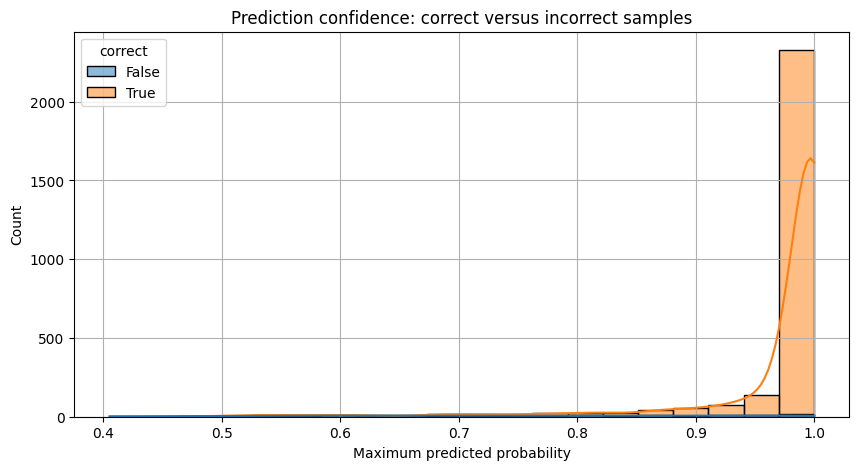

In [31]:
# Use SVM RBF probabilities from the classical baseline when available.
prob_model_name = "SVM RBF"
if prob_model_name in fitted_classical_models:
    prob_model = fitted_classical_models[prob_model_name]
    if hasattr(prob_model, "predict_proba"):
        probs = prob_model.predict_proba(X_test_feat)
        pred = classical_predictions[prob_model_name]
        confidence = probs.max(axis=1)
        correct = (pred == y_test.values)
        confidence_df = pd.DataFrame({
            "confidence": confidence,
            "correct": correct,
            "true_activity": y_test.map(id_to_activity).values,
            "predicted_activity": pd.Series(pred).map(id_to_activity).values
        })
        display(confidence_df.groupby("correct")["confidence"].agg(["count", "mean", "median", "min", "max"]).round(4))

        fig, ax = plt.subplots()
        sns.histplot(data=confidence_df, x="confidence", hue="correct", bins=20, kde=True, ax=ax)
        ax.set_title("Prediction confidence: correct versus incorrect samples")
        ax.set_xlabel("Maximum predicted probability")
        plt.show()
    else:
        print("The selected model does not expose predict_proba.")


## Interpretation and practical lessons

Interpret the notebook around three questions.

First, are handcrafted features already strong? In UCI HAR, the official feature matrix is carefully engineered from accelerometer and gyroscope windows. If classical SVM or Random Forest performs very well, that is expected and should not be treated as a failure of deep learning. It shows that expert feature engineering can encode much of the relevant temporal and frequency information.

Second, do raw-signal models add value? A 1D CNN can learn local motion fragments directly from the sequence, while GRU/LSTM models process the ordered window through recurrent states. The Transformer compares time steps through attention. If these models do not clearly outperform the feature baseline, possible explanations include limited training epochs, small model capacity, clean handcrafted features, or insufficient need for long-range temporal modeling within 128-step windows.

Third, where do errors occur? Overall accuracy can look high while sitting versus standing or upstairs versus downstairs remains confused. The normalized confusion matrix, ranked confusion-pair table, and misclassified-signal plots are therefore more informative than a single score.

Finally, compare complexity to benefit. A classical SVM on official features may be easier to train, faster to tune, and more stable. A raw CNN may be preferable when handcrafted features are unavailable, when the sensor setup changes, or when representation learning can transfer to related tasks.


## Limitations

The UCI HAR dataset is useful for teaching but cleaner than many real deployments.

- Windows are already segmented and labeled, while real systems must handle streaming data and activity transitions.
- The phone placement and subject behavior in the dataset may not represent every user or device.
- The official handcrafted features are unusually strong, so results may overstate the performance of classical feature-based pipelines compared with raw real-world data.
- The deep models are intentionally lightweight and trained for a small number of epochs to keep the notebook practical. Stronger tuning may change the ranking.
- Cropping fixed windows is only a proxy for true window-size experiments. A full study would reconstruct continuous signals and re-window them with different lengths and overlaps.
- Subject-aware validation is essential in wearable sensing because random row-wise splits can leak person-specific movement style.
- Real-time deployment must consider latency, battery use, memory, sensor noise, and confidence calibration.


## What we learned

- Time series classification uses temporal patterns inside each window.
- Handcrafted features can be extremely strong for sensor classification.
- CNNs learn local temporal patterns from raw sequences.
- GRU/LSTM models process sequences through recurrent hidden states.
- Transformers use attention across time positions but need careful design.
- Class-wise evaluation and error analysis are essential.

## Possible extensions

Useful extensions include subject-independent validation, signal augmentation, contrastive learning for time series, streaming/online classification, wearable health monitoring, ECG classification, time-series anomaly detection, and explainable AI for sensor models.